In [2]:
import pandas as pd
df = pd.read_csv("customer_churn_dataset-testing-master.csv.zip")
df.head(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 5.9 MB


CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Missing values before cleaning:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

After dropping rows with missing values:
(64374, 12)

Categorical columns: ['Gender', 'Subscription Type', 'Contract Length']
Numeric columns: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

Churn distribution:
Churn
0    0.526315
1    0.473685
Name: proportion, dtype: float64


C:\Users\my pc\AppData\Local\Temp\ipykernel_5620\160944301.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = _df.select_dtypes(include=['object']).columns.tolist()


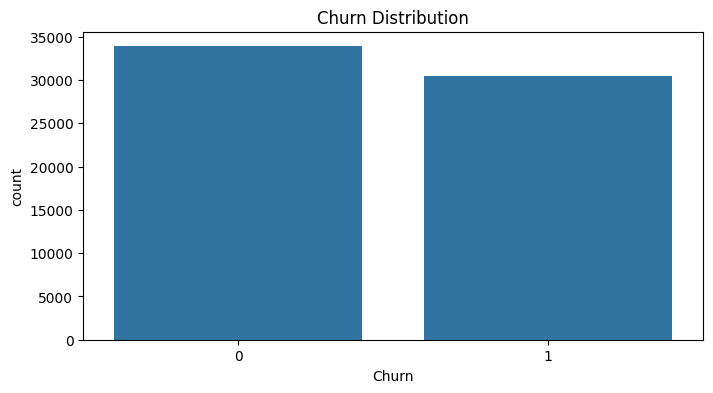

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Clean and normalize column names
_df = df.copy()
_df.columns = _df.columns.str.strip()

# Convert numeric columns stored as text
if 'TotalCharges' in _df.columns:
    _df['TotalCharges'] = pd.to_numeric(_df['TotalCharges'], errors='coerce')

# Handle missing values
print('Missing values before cleaning:')
print(_df.isnull().sum())
_df = _df.dropna()
print('\nAfter dropping rows with missing values:')
print(_df.shape)

# Define target and features
if 'customerID' in _df.columns:
    _df = _df.drop(columns=['customerID'])
elif 'CustomerID' in _df.columns:
    _df = _df.drop(columns=['CustomerID'])

target_col = 'Churn' if 'Churn' in _df.columns else _df.columns[-1]

categorical_cols = _df.select_dtypes(include=['object']).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

numeric_cols = _df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
print('\nCategorical columns:', categorical_cols)
print('Numeric columns:', numeric_cols)

# EDA: churn balance and numeric distributions
print('\nChurn distribution:')
print(_df[target_col].value_counts(normalize=True))

plt.figure(figsize=(8, 4))
sns.countplot(data=_df, x=target_col)
plt.title('Churn Distribution')
plt.show()

if 'MonthlyCharges' in _df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=_df, x='MonthlyCharges', kde=True, bins=30)
    plt.title('Monthly Charges Distribution')
    plt.show()

Accuracy: 0.9981359223300971

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



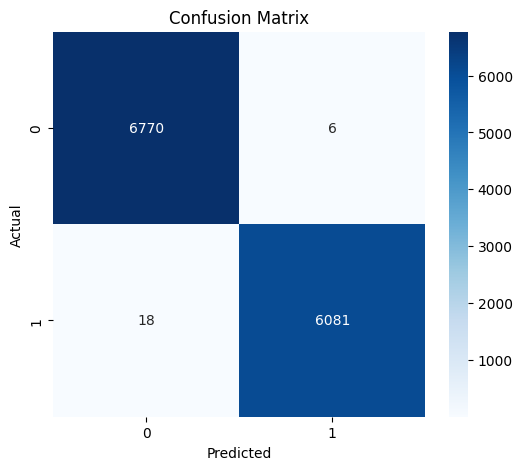

In [ ]:
# Prepare data for modeling
encoded_df = pd.get_dummies(_df, columns=categorical_cols, drop_first=True)

# If target is still object, map yes/no to 1/0
if encoded_df[target_col].dtype == 'object':
    encoded_df[target_col] = encoded_df[target_col].map({'Yes': 1, 'No': 0})

X = encoded_df.drop(columns=[target_col])
y = encoded_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, predictions))
print('\nClassification Report:')
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature importance and correlation heatmap
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nTop 10 feature importances:')
print(feature_importances.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importances.head(10), y=feature_importances.head(10).index)
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [12]:
# Summary: Model Performance and Key Insights
print("="*50)
print("MODEL SUMMARY")
print("="*50)
print(f"\nModel Type: Random Forest Classifier")
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"\nDataset Shape: {_df.shape}")
print(f"Training Set: {X_train.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")
print(f"\nFeatures Used: {X.shape[1]}")
print(f"Target Class Distribution:\n{y.value_counts(normalize=True)}")

# Calculate feature importance in this cell
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 3 Most Important Features:")
for i, (feature, importance) in enumerate(feature_importances.head(3).items(), 1):
    print(f"  {i}. {feature}: {importance:.4f}")

MODEL SUMMARY

Model Type: Random Forest Classifier
Accuracy: 0.9981

Dataset Shape: (64374, 11)
Training Set: 51499 samples
Test Set: 12875 samples

Features Used: 12
Target Class Distribution:
Churn
0    0.526315
1    0.473685
Name: proportion, dtype: float64

Top 3 Most Important Features:
  1. Payment Delay: 0.4447
  2. Support Calls: 0.1635
  3. Tenure: 0.1028
